In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding signal
chec_sumprom_glob = "sumproms/*.gz"

# Yeast promoter-level chec-seq binding signal (see manuscript for source)
native_tf_sumprom_glob = "../Yeast_Native_TF_outfiles/results/sumproms/*.gz"

# Motif binding score directory (see analysis code for calculation)
binding_score_base_dir = "binding_score_at_motifs"
background_binding_dir = f"{binding_score_base_dir}/background_binding_arrays"

individual_regex_search = ["__*loc-prom__*type-individual__fl25__*.csv"]
representative_regex_search = ["__*loc-prom__*family*__fl25__*.csv"]
yeast_individual_regex_search = ["__*loc-prom__*type-yeast__fl25__*.csv"]
yeast_representative_regex_search = ["__*loc-prom__*type-human_family_cross__fl25__*.csv"]
background_array_pattern = "__*__loc-prom__signal_bg__fl25*.npy"

## Imports

In [3]:
import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, FuncFormatter

## Helper Functions

In [4]:
# Load one motif table and its matched background array
def load_sample(sample_name, regex_search):
    # Collect all matching motif-table files
    df_files = []
    for pattern in regex_search:
        df_files.extend(
            glob.glob(f"{binding_score_base_dir}/{sample_name}/{sample_name}{pattern}")
        )

    # Require exactly one matched motif table
    if len(df_files) != 1:
        return None, None

    # Require exactly one matched background array
    bg_files = glob.glob(
        f"{background_binding_dir}/{sample_name}{background_array_pattern}"
    )
    if len(bg_files) != 1:
        return None, None

    # Load the motif table and the background z-score column
    df = pd.read_csv(df_files[0])
    z_bg = np.load(bg_files[0])[:, 1]
    return z_bg, df


# Keep only samples with reproducible replicate signal
def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()

    # Group replicate columns by sample name
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        # Skip samples with fewer than two replicates
        if len(members) < 2:
            continue

        # Compute replicate-replicate correlations within each sample
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)

        # Keep replicates that correlate above the cutoff with at least one partner
        max_corrs = corr.max(axis=1)
        keep.extend(max_corrs[max_corrs >= cutoff].index.tolist())

    return df[keep]


# Return a DataFrame from dict values that may already be tuples
def _as_df(obj):
    if obj is None:
        return None
    if isinstance(obj, tuple):
        obj = obj[-1]
    return obj if isinstance(obj, pd.DataFrame) else None


# Compute the local percent of bound motifs after sorting by nucleosome score
def local_curve(df: pd.DataFrame, frac: float = 0.15, z_thr: float = 3.0):
    # Parse the nucleosome and binding columns
    nuc = pd.to_numeric(df["nuc_score_f7"], errors="coerce")
    z = pd.to_numeric(df["z_score_norm_f7"], errors="coerce")

    # Keep only rows with both values present
    m = nuc.notna() & z.notna()
    if m.sum() == 0:
        return np.array([]), np.array([])

    # Sort motifs by nucleosome score
    d = pd.DataFrame({"nuc": nuc[m], "z": z[m]}).sort_values("nuc")
    x = d["nuc"].to_numpy(float)

    # Mark bound motifs
    hit = (d["z"] > z_thr).astype(float)

    # Use a sliding window of ±frac of total motifs
    half_window = max(1, int(frac * len(d)))
    win = 2 * half_window + 1

    # Smooth signal with centered rolling window
    y = (
        100.0
        * hit.rolling(window=win, center=True, min_periods=1)
        .mean()
        .to_numpy(float)
    )

    return x, y


# Pick the local-curve value nearest to a nucleosome percentile
def y_at_percentile_from_curve(x_sorted, y_local, nuc_vals, pct):
    # Convert the requested percentile into a nucleosome-score position
    x0 = np.percentile(nuc_vals, pct)
    i = np.searchsorted(x_sorted, x0)

    # Handle values that fall beyond the curve range
    if i <= 0:
        return float(y_local[0])
    if i >= len(x_sorted):
        return float(y_local[-1])

    # Return the nearest curve value
    if abs(x_sorted[i] - x0) < abs(x_sorted[i - 1] - x0):
        return float(y_local[i])
    return float(y_local[i - 1])


# Same local-curve helper used by the scatter + line plot
def local_pct_z_gt3_vs_nuc(df: pd.DataFrame, frac: float = 0.15) -> tuple[np.ndarray, np.ndarray]:
    if df is None or "nuc_score_f7" not in df or "z_score_norm_f7" not in df:
        return np.array([]), np.array([])
    return local_curve(df, frac=frac, z_thr=3.0)

## Data Loading

In [5]:
# Define TF families and display labels
FOXK1_WT = ["FOXK1", "FOXP3", "FOXA2", "FOXF1", "FOXL1", "FOXL2", "FOXJ2", "FOXO3", "FOXP1", "FOXP2"]
GABPA_WT = ["ELF1", "ELF2", "ERF1", "ELK1", "ELK4", "ERG", "FLI1"]
SOX10_WT = ["SOX15", "SOX17", "SOX7", "SOX11", "SOX4", "SOX6", "SOX30", "SOX9", "SOX13", "SOX5"]
HXD10_WT = ["CDX2", "HOXA11", "HOXC10", "HOXD9", "HOXA10", "HOXC9", "HOXA9", "HOXB9", "CDX4", "HOXC13"]
GATA1_WT = ["GATA3", "GATA6", "GATA4", "GATA2", "GATA5"]
BATF3_WT = ["ATF4", "FOS", "CREB5", "ATF1", "CREB1", "ATF2"]
HEY1_WT = ["MNT", "MLXIPL", "MLX", "MXD4"]
NFAC4_WT = ["NFAT5", "NFATC4", "NFATC3"]
TF2LY_WT = ["TGIF2LX", "TGIF2LY", "TGIF1", "TGIF2"]
PO3F2_WT = ["POU2F3", "POU3F4", "POU3F1"]

dbd_fam_dict = {
    "FOXK1": FOXK1_WT,
    "GABPA": GABPA_WT,
    "SOX10": SOX10_WT,
    "HXD10": HXD10_WT,
    "GATA1": GATA1_WT,
    "BATF3": BATF3_WT,
    "HEY1": HEY1_WT,
    "NFAC4": NFAC4_WT,
    "TF2LY": TF2LY_WT,
    "PO3F2": PO3F2_WT,
}

exists_in_yeast = {
    "FOXK1": "yes",
    "GABPA": "no",
    "SOX10": "no",
    "HXD10": "no",
    "GATA1": "yes",
    "BATF3": "yes",
    "HEY1": "yes",
    "NFAC4": "no",
    "TF2LY": "no",
    "PO3F2": "no",
}

all_samples = set(sum(dbd_fam_dict.values(), []))

family_name = {
    "BATF3": "bZIP",
    "FOXK1": "Forkhead",
    "GABPA": "ETS",
    "HEY1": "bHLH",
    "HXD10": "Homeodomain\nHOX",
    "NFAC4": "Rel",
    "SOX10": "SOX",
    "TF2LY": "Homeodomain\nTALE-Type",
    "PO3F2": "Homeodomain\nPOU",
    "GATA1": "GATA",
}

yeast_bzips = ["Yap1", "Yap2", "Yap3", "Yap4", "Yap5", "Yap6", "Yap7", "Gcn4_lowN", "Aca1", "Sko1", "Hac1", "Cst6", "Phd1"]
yeast_gata = ["Gln3", "Gat1", "Dal80", "Gzf3"]
yeast_forkheads = ["Fkh1", "Fkh2", "Hcm1", "Fhl1"]

plotting_order_fam = ["FOXK1", "BATF3", "GATA1", "HEY1", "GABPA", "NFAC4", "TF2LY", "PO3F2", "HXD10", "SOX10"]

In [6]:
# Load human promoter summaries from all sequencing batches
chec_sumprom_files = glob.glob(chec_sumprom_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in chec_sumprom_files], axis=1)

corr_cutoff = 0.895
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit("_", n=2).str[0]
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
good_samples = sumprom.columns[sumprom.columns.isin(all_samples)].tolist()

# Load yeast promoter summaries
native_tf_sumprom_files = glob.glob(native_tf_sumprom_glob)
native_tf_sumprom = pd.concat([pd.read_parquet(x) for x in native_tf_sumprom_files], axis=1)
non_transcription_factors = ["Nfi1", "Itc1", "Gal11", "Nhp6A", "Spt20", "Nhp6B", "Abf2", "Tog1", "Siz1", "Cyc8", "Mss11"]
native_tf_sumprom = native_tf_sumprom.drop(columns=non_transcription_factors)
yeast_tfs = native_tf_sumprom.columns

## Data Processing

In [7]:
# Load motif-level human and yeast tables used by the downstream plots
df_dict_individual = {
    sample: load_sample(sample, regex_search=individual_regex_search)[1]
    for sample in good_samples
}

bg_dict = {}
df_dict_representative = {}
for sample in good_samples:
    bg_dict[sample], df_dict_representative[sample] = load_sample(
        sample, regex_search=representative_regex_search
    )

df_dict_yeast_individual = {
    sample: load_sample(sample, regex_search=yeast_individual_regex_search)[1]
    for sample in yeast_tfs
}

df_dict_yeast_representative = {
    sample: load_sample(sample, regex_search=yeast_representative_regex_search)[1]
    for sample in yeast_tfs
}

# Set spacing used for the rotated family bar plot
spacing = 2.0
gap_between = 2.0

# Compute the percent of bound motifs and motif count for one representative TF
def pct_z_gt3_and_n(sample):
    df = df_dict_representative.get(sample)
    if df is None or "z_score_norm_f7" not in df:
        return None, None

    z = df["z_score_norm_f7"].to_numpy(dtype=float)
    valid = ~np.isnan(z)
    if not valid.any():
        return None, None

    return 100.0 * (z[valid] > 3).mean(), len(df)

# Collect the representative TF values used to order families
pct_map = {}
n_map = {}
for fam in plotting_order_fam:
    for s in dbd_fam_dict.get(fam, []):
        if s not in good_samples:
            continue
        pct, n = pct_z_gt3_and_n(s)
        if pct is not None:
            pct_map[s] = pct
            n_map[s] = n

# Build sample order, x positions, and family ranges for the rotated bar plot
samples = []
x_positions = []
fam_ranges = []
family_n_to_plot = {}
x_current = 0.0
idx = 0

for fam in plotting_order_fam:
    fam_samples = [s for s in dbd_fam_dict.get(fam, []) if s in pct_map]
    if not fam_samples:
        continue

    # Order TFs within a family from highest to lowest percent bound
    fam_samples.sort(key=lambda s: pct_map[s], reverse=True)

    fam_ns = [n_map[s] for s in fam_samples]
    n0 = fam_ns[0]
    if any(n != n0 for n in fam_ns[1:]):
        discrep = sorted(set(fam_ns))
        print(
            f"[DISCREPANCY] Family {fam}: motif counts differ across plotted samples: {discrep}. "
            f"Using n={n0} from first plotted sample ({fam_samples[0]})."
        )
    family_n_to_plot[fam] = n0

    start = idx
    for s in fam_samples:
        samples.append(s)
        x_positions.append(x_current)
        x_current += spacing
        idx += 1
    fam_ranges.append((fam, start, idx - 1))
    x_current += gap_between

x = np.array(x_positions)

# Build the summary table used by plots 2-4
frac = 0.1
rows = []

for sample, obj in df_dict_representative.items():
    df = _as_df(obj)
    if df is None or "nuc_score_f7" not in df or "z_score_norm_f7" not in df:
        continue

    nuc = pd.to_numeric(df["nuc_score_f7"], errors="coerce").to_numpy(float)
    z = pd.to_numeric(df["z_score_norm_f7"], errors="coerce").to_numpy(float)
    m = np.isfinite(nuc) & np.isfinite(z)
    nuc, z = nuc[m], z[m]
    if nuc.size == 0:
        continue

    # Basic bound and nucleosome summary statistics
    bound = z > 3
    pct_bound_total = 100.0 * bound.mean()

    mean_all = float(np.mean(nuc))
    mean_bound = float(np.mean(nuc[bound])) if bound.any() else np.nan
    delta_mean_nuc = mean_bound - mean_all

    low_mask = nuc < 0.5
    high_mask = nuc > 1.0
    pct_bound_low = 100.0 * bound[low_mask].mean() if low_mask.any() else np.nan
    pct_bound_high = 100.0 * bound[high_mask].mean() if high_mask.any() else np.nan

    # Compute the local enrichment curve across nucleosome score
    x_curve, y_curve = local_curve(df, frac=frac)
    if x_curve.size == 0:
        continue

    y5 = y_at_percentile_from_curve(x_curve, y_curve, nuc, 5)
    y95 = y_at_percentile_from_curve(x_curve, y_curve, nuc, 95)
    log_ratio_95_5 = (
        np.log2(y95 / y5)
        if (np.isfinite(y5) and np.isfinite(y95) and y5 > 0 and y95 > 0)
        else np.nan
    )   

    i_max = int(np.nanargmax(y_curve))
    i_min = int(np.nanargmin(y_curve))
    denom = x_curve[i_max] - x_curve[i_min]
    slope = (
        (y_curve[i_max] - y_curve[i_min]) / denom
        if (np.isfinite(denom) and denom != 0)
        else np.nan
    )

    rows.append(
        {
            "sample": sample,
            "pct_bound_total": pct_bound_total,
            "delta_mean_nuc": delta_mean_nuc,
            "log_ratio_95_5": log_ratio_95_5,
            "slope": slope,
            "pct_bound_low": pct_bound_low,
            "pct_bound_high": pct_bound_high,
        }
    )

dfm = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan)
dfm = dfm[dfm["sample"].isin(good_samples)]

## Plotting

/tmp/ipykernel_882993/3945147018.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


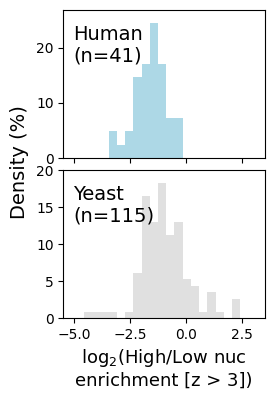

In [8]:
Z_THR = 3.0

# Fraction of all bound motifs that fall inside a given mask
def frac_of_all_z_gt3_in_mask(df, mask):
    z = pd.to_numeric(df["z_score_norm_f7"], errors="coerce").to_numpy(float)
    z_ok = np.isfinite(z)
    z_gt = z_ok & (z > Z_THR)
    denom = int(z_gt.sum())
    if denom == 0:
        return None
    num = int((z_gt & mask).sum())
    return num / denom


# Compare the top and bottom nucleosome quartiles within one TF
def ratio_topq_botq_for_df(df, q_low=0.25, q_high=0.75):
    if df is None or ("nuc_score_f7" not in df) or ("z_score_norm_f7" not in df):
        return None

    nuc_all = pd.to_numeric(df["nuc_score_f7"], errors="coerce").to_numpy(float)
    nuc_ok = np.isfinite(nuc_all)
    nuc = nuc_all[nuc_ok]
    if nuc.size == 0:
        return None

    lo_thr = np.quantile(nuc, q_low)
    hi_thr = np.quantile(nuc, q_high)

    low_mask = nuc_ok & (nuc_all <= lo_thr)
    high_mask = nuc_ok & (nuc_all >= hi_thr)

    f_low = frac_of_all_z_gt3_in_mask(df, low_mask)
    f_high = frac_of_all_z_gt3_in_mask(df, high_mask)

    if (f_low is None) or (f_high is None) or (f_low <= 0) or (f_high <= 0):
        return None

    return np.log2((f_high + 1e-12) / (f_low + 1e-12))


# Collect the per-TF metric for a dictionary of motif tables
def collect_metric(df_dict):
    vals = []
    for _, df in df_dict.items():
        v = ratio_topq_botq_for_df(df)
        if v is not None and np.isfinite(v):
            vals.append(v)
    return np.array(vals, float)


# Compute per-TF metrics for human and yeast
logged = collect_metric(df_dict_individual)
logged1 = collect_metric(df_dict_yeast_individual)

if logged.size == 0 and logged1.size == 0:
    print("[warn] No valid metrics for either group")
else:
    combined_min = np.min([a.min() for a in [logged, logged1] if a.size > 0])
    combined_max = np.max([a.max() for a in [logged, logged1] if a.size > 0])
    shared_range = (combined_min, combined_max)

    bins = 19

    counts0, edges = np.histogram(logged, bins=bins, range=shared_range) if logged.size > 0 else (np.zeros(bins, int), None)
    counts1, _ = np.histogram(logged1, bins=bins, range=shared_range) if logged1.size > 0 else (np.zeros(bins, int), edges)

    h0 = counts0 * 100.0 / len(logged) if logged.size > 0 else np.zeros(bins, float)
    h1 = counts1 * 100.0 / len(logged1) if logged1.size > 0 else np.zeros(bins, float)

    bin_widths = np.diff(edges)
    bin_lefts = edges[:-1]

    fig = plt.figure(figsize=(2.6, 4))
    gs = fig.add_gridspec(2, 1, hspace=0.08)

    ax_top = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1], sharex=ax_top)

    if logged.size > 0:
        ax_top.bar(bin_lefts, h0, width=bin_widths, color="lightblue")
    if logged1.size > 0:
        ax_mid.bar(bin_lefts, h1, width=bin_widths, color="lightgrey", alpha=0.7)

    ax_top.set_ylim(0, (h0.max() if h0.size else 1) * 1.1)
    ax_mid.set_ylim(0, (h1.max() if h1.size else 1) * 1.1)
    ax_top.set_xlim(-5.5, 3.5)
    ax_mid.set_xlim(-5.5, 3.5)

    ax_top.tick_params(labelbottom=False)

    ax_top.text(0.05, 0.9, f"Human\n(n={len(logged)})", transform=ax_top.transAxes, ha="left", va="top", fontsize=14)
    ax_mid.text(0.05, 0.9, f"Yeast\n(n={len(logged1)})", transform=ax_mid.transAxes, ha="left", va="top", fontsize=14)

    fig.supylabel("Density (%)", fontsize=14, x=-0.08)
    ax_mid.set_xlabel(r"log$_{2}$(High/Low nuc" "\n" "enrichment [z > 3])", fontsize=13)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_882993/4160853951.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


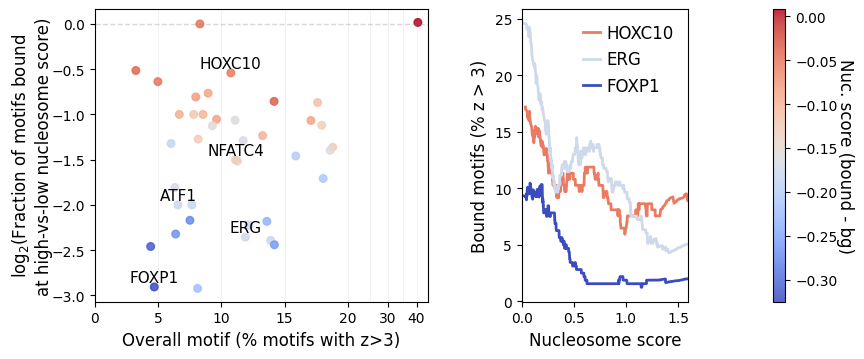

In [9]:
# Plot scatter of TF-level metrics and selected local binding curves
def plot_scatter_plus_localcurves(dfm, df_dict, frac=0.15):

    # Extract values used for scatter plot
    X = dfm["pct_bound_total"].to_numpy(float)
    Y = dfm["log_ratio_95_5"].to_numpy(float)
    C = dfm["delta_mean_nuc"].to_numpy(float)

    # Keep only valid rows
    ok = np.isfinite(X) & np.isfinite(Y) & np.isfinite(C)
    X, Y, C = X[ok], Y[ok], C[ok]
    labels = dfm.loc[ok, "sample"].astype(str).to_numpy()

    # Set up colormap based on nucleosome difference
    cmap = plt.get_cmap("coolwarm")
    norm = Normalize(vmin=np.nanmin(C), vmax=np.nanmax(C))
    color_by_sample = dict(zip(labels, cmap(norm(C))))

    # Create figure with scatter + line plot + colorbar
    fig = plt.figure(figsize=(9, 3.8))
    gs = fig.add_gridspec(1, 3, width_ratios=[2.6, 1.3, 0.08], wspace=0.55)

    ax_sc = fig.add_subplot(gs[0, 0])  # scatter
    ax_ln = fig.add_subplot(gs[0, 1])  # line plot
    cax = fig.add_subplot(gs[0, 2])    # colorbar

    # ---- Scatter plot ----
    sc = ax_sc.scatter(X, Y, c=C, s=30, alpha=0.85, cmap=cmap, norm=norm)

    ax_sc.set_xlabel("Overall motif (% motifs with z>3)", fontsize=12)
    ax_sc.set_ylabel(
        r"log$_{2}$(Fraction of motifs bound" "\n"
        r"at high-vs-low nucleosome score)",
        labelpad=-1, fontsize=12
    )

    # Log-like scaling on x-axis (same as original)
    ax_sc.set_xscale("symlog", linthresh=20)
    ax_sc.set_xlim(0, 45)
    for xv in np.arange(0, 46, 5):
        ax_sc.axvline(xv, color="gray", alpha=0.15, lw=0.5, zorder=0)
    ax_sc.set_xticks([0, 5, 10, 15, 20, 30, 40])
    ax_sc.xaxis.set_major_formatter(FormatStrFormatter('%d'))

    # Reference line at y=0
    ax_sc.axhline(0, ls="--", lw=1, color="gray", alpha=0.3)

    # Label selected TFs on scatter
    highlight = {"ERG", "ATF1", "HOXC10", "FOXP1", "NFATC4"}
    for x, y, lab in zip(X, Y, labels):
        if lab in highlight:
            ax_sc.text(x, y + 0.02, lab, fontsize=11, ha="center", va="bottom")

    # ---- Line plots (local curves) ----
    for s in ["HOXC10", "ERG", "FOXP1"]:
        obj = df_dict.get(s)
        df = obj[-1] if isinstance(obj, tuple) else obj
        if not isinstance(df, pd.DataFrame):
            continue

        x_curve, y_curve = local_pct_z_gt3_vs_nuc(df)
        if x_curve.size == 0:
            continue

        ax_ln.plot(
            x_curve, y_curve,
            linewidth=2.0,
            color=color_by_sample.get(s, "black"),
            label=s
        )

    ax_ln.set_xlabel("Nucleosome score", fontsize=12)
    ax_ln.set_ylabel("Bound motifs (% z > 3)", fontsize=12)
    ax_ln.set_xlim(0, 1.6)
    ax_ln.xaxis.set_major_locator(MultipleLocator(0.5))
    ax_ln.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax_ln.legend(frameon=False, fontsize=12, loc="upper right", handlelength=1.0, handletextpad=0.4)

    # ---- Colorbar ----
    cb = fig.colorbar(sc, cax=cax)
    cb.set_label("Nuc. score (bound - bg)", rotation=270, labelpad=12, fontsize=12)

    # Slightly widen colorbar (same visual tweak)
    pos = cax.get_position()
    cax.set_position([pos.x0 - 0.01, pos.y0, pos.width * 1.2, pos.height])

    fig.tight_layout()
    return fig


# Generate the plot
fig = plot_scatter_plus_localcurves(dfm, df_dict_representative)
plt.show()

ATF1: x=47.17, y=13.21
ATF2: x=30.77, y=14.29
CDX2: x=43.14, y=21.57
CDX4: x=54.05, y=13.51
CREB1: x=30.43, y=15.94
ELF1: x=40.30, y=10.45
ELF2: x=34.93, y=17.12
ELK1: x=31.38, y=18.09
ELK4: x=28.21, y=22.44
ERF1: x=37.68, y=14.98
ERG: x=38.17, y=9.16
FLI1: x=39.22, y=9.80
FOXA2: x=37.28, y=14.20
FOXF1: x=53.75, y=12.50
FOXJ2: x=41.67, y=13.54
FOXO3: x=43.71, y=10.60
FOXP1: x=50.00, y=10.00
FOXP2: x=48.94, y=10.64
FOXP3: x=50.00, y=13.24
GATA2: x=44.23, y=13.46
GATA3: x=46.03, y=15.87
GATA4: x=44.30, y=22.78
GATA6: x=40.66, y=16.48
HOXA11: x=43.06, y=13.89
HOXB9: x=39.58, y=14.58
HOXC10: x=34.85, y=21.21
HOXC13: x=41.82, y=18.18
HOXC9: x=42.86, y=18.37
HOXD9: x=43.90, y=17.07
MLX: x=25.53, y=25.53
MNT: x=0.00, y=0.00
NFATC3: x=33.61, y=14.75
NFATC4: x=30.12, y=11.45
POU3F1: x=55.26, y=0.00
POU3F4: x=45.83, y=6.25
SOX13: x=30.30, y=22.73
SOX17: x=45.56, y=12.78
SOX5: x=34.15, y=13.82
SOX6: x=34.88, y=18.60
TGIF1: x=44.79, y=21.47
TGIF2: x=42.60, y=18.93
TGIF2LX: x=39.38, y=21.88


/tmp/ipykernel_882993/595161021.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.88])


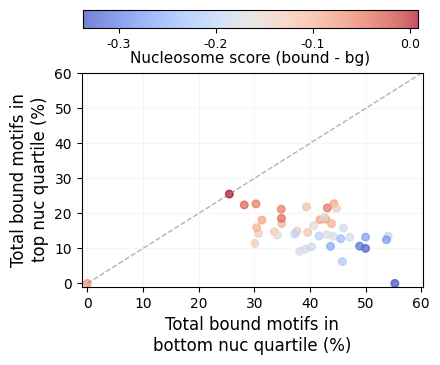

(<Figure size 450x360 with 2 Axes>,
 <Axes: xlabel='Total bound motifs in\nbottom nuc quartile (%)', ylabel='Total bound motifs in\ntop nuc quartile (%)'>)

In [10]:
# Compute % of bound motifs (z > cutoff) in low/high nucleosome quartiles
def pct_nuc_quartile_among_bound(
    df, *, z_cutoff, mode, q_low=0.25, q_high=0.75
):
    # Basic input validation
    if df is None or "nuc_score_f7" not in df or "z_score_norm_f7" not in df:
        return None

    # Convert columns to numeric arrays
    nuc = pd.to_numeric(df["nuc_score_f7"], errors="coerce").to_numpy(float)
    z   = pd.to_numeric(df["z_score_norm_f7"], errors="coerce").to_numpy(float)

    # Keep only rows with valid values
    valid = np.isfinite(nuc) & np.isfinite(z)
    if not valid.any():
        return None

    # Compute quartile thresholds from all valid nucleosome values
    nuc_valid = nuc[np.isfinite(nuc)]
    if nuc_valid.size == 0:
        return None
    lo_thr = np.quantile(nuc_valid, q_low)
    hi_thr = np.quantile(nuc_valid, q_high)

    # Keep only bound motifs
    bound = valid & (z > float(z_cutoff))
    if not bound.any():
        return None

    nuc_bound = nuc[bound]

    # Return % in chosen quartile
    if mode == "low":
        return 100.0 * (nuc_bound <= lo_thr).mean()
    if mode == "high":
        return 100.0 * (nuc_bound >= hi_thr).mean()

    raise ValueError("mode must be 'low' or 'high'")


# Scatter: bottom vs top quartile occupancy among bound motifs
def scatter_low_vs_high_nuc_quartile_among_bound_colored_like_dfm(
    df_dict_representative,
    dfm,
    *,
    sample_col="sample",
    ccol="delta_mean_nuc",
    z_cutoff_bound=3.0,
    q_low=0.25,
    q_high=0.75,
    annotate=False,
):
    # --- Build color mapping from dfm ---
    dfm_ok = dfm[[sample_col, ccol]].dropna()
    cmap = plt.get_cmap("coolwarm")
    norm = Normalize(vmin=dfm_ok[ccol].min(), vmax=dfm_ok[ccol].max())

    c_by_sample = dict(zip(
        dfm_ok[sample_col].astype(str),
        dfm_ok[ccol].astype(float),
    ))

    # --- Compute x/y values per TF ---
    xs, ys, Cs, labels = [], [], [], []

    for sample, df in df_dict_representative.items():
        lab = str(sample)

        # % bound motifs in bottom vs top quartile
        x = pct_nuc_quartile_among_bound(
            df, z_cutoff=z_cutoff_bound, mode="low", q_low=q_low, q_high=q_high
        )
        y = pct_nuc_quartile_among_bound(
            df, z_cutoff=z_cutoff_bound, mode="high", q_low=q_low, q_high=q_high
        )

        # Skip invalid or missing data
        if (
            x is None or y is None or
            not (np.isfinite(x) and np.isfinite(y)) or
            lab not in c_by_sample
        ):
            continue

        xs.append(x)
        ys.append(y)
        Cs.append(c_by_sample[lab])
        labels.append(lab)

    if not xs:
        return None, None

    xs = np.asarray(xs, float)
    ys = np.asarray(ys, float)
    Cs = np.asarray(Cs, float)

    # Print values for inspection
    for lab, x, y in zip(labels, xs, ys):
        print(f"{lab}: x={x:.2f}, y={y:.2f}")

    # --- Create scatter plot ---
    fig, ax = plt.subplots(figsize=(4.5, 3.6))
    sc = ax.scatter(xs, ys, c=Cs, cmap=cmap, norm=norm, s=30, alpha=0.7)

    # Optional point labels
    if annotate:
        for x, y, lab in zip(xs, ys, labels):
            ax.text(x + 0.6, y + 0.6, lab, fontsize=7, alpha=0.8)

    # Diagonal reference line
    max_xy = max(xs.max(), ys.max())
    ax.plot([0, max_xy + 5], [0, max_xy + 5], "--", color="gray", lw=1, alpha=0.6)

    # Axis formatting
    ax.set_xlabel("Total bound motifs in\nbottom nuc quartile (%)", fontsize=12)
    ax.set_ylabel("Total bound motifs in\ntop nuc quartile (%)", fontsize=12)
    ax.set_xlim(-1, max_xy + 5)
    ax.set_ylim(-1, max_xy + 5)
    ax.grid(alpha=0.1)

    # --- Top colorbar (aligned with plot) ---
    pos = ax.get_position()
    cax = fig.add_axes([
        pos.x0 + 0.07,
        pos.y1 + 0.07,
        pos.width - 0.03,
        0.05
    ])

    cbar = fig.colorbar(sc, cax=cax, orientation="horizontal")
    cbar.set_ticks([0, -0.1, -0.2, -0.3])
    cbar.ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    cbar.set_label("Nucleosome score (bound - bg)", fontsize=11, labelpad=0)
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

    return fig, ax


# Generate the plot
scatter_low_vs_high_nuc_quartile_among_bound_colored_like_dfm(
    df_dict_representative=df_dict_representative,
    dfm=dfm,
    ccol="delta_mean_nuc",
    annotate=False
)

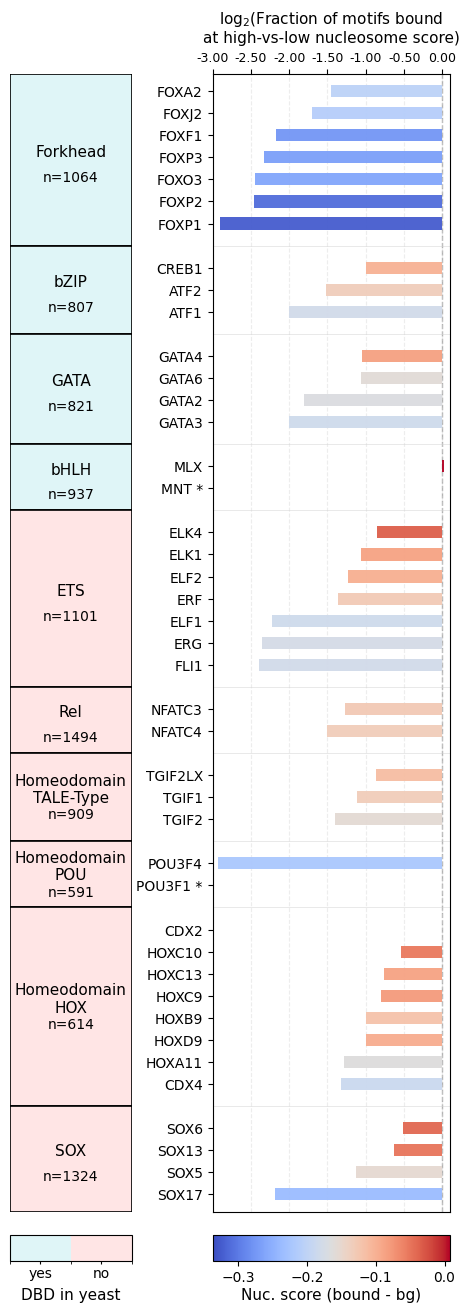

In [11]:
# Build the rotated family-ordered bar plot
val_col = "log_ratio_95_5"
c_col = "delta_mean_nuc"

dfm_idx = dfm.set_index("sample", drop=False)

vals = np.array([dfm_idx.at[s, val_col] if s in dfm_idx.index else np.nan for s in samples], dtype=float)
Craw = np.array([dfm_idx.at[s, c_col] if s in dfm_idx.index else np.nan for s in samples], dtype=float)

cmap = plt.get_cmap("coolwarm")
okC = np.isfinite(Craw)
if okC.any():
    norm = Normalize(vmin=np.nanmin(Craw[okC]), vmax=np.nanmax(Craw[okC]))
else:
    norm = Normalize(vmin=-1, vmax=1)

colors_raw = np.empty((len(samples), 4), float)
colors_raw[:] = (0.6, 0.6, 0.6, 1.0)
for i in range(len(samples)):
    if np.isfinite(Craw[i]):
        colors_raw[i] = cmap(norm(Craw[i]))

samples_v = []
vals_v = []
ypos_v = []
colors_v = []
fam_ranges_v = []
exists_v = {}
family_n_v = {}
name_v = {}

idx0 = 0
for fam, start, end in fam_ranges:
    fam_idx = list(range(start, end + 1))

    def _sort_key(i):
        v = vals[i]
        return v if np.isfinite(v) else -np.inf

    fam_idx_sorted = sorted(fam_idx, key=_sort_key, reverse=True)

    pos_slice = np.array(x[start:end + 1], dtype=float)
    pos_slice = np.sort(pos_slice)

    samples_v.extend([samples[i] for i in fam_idx_sorted])
    vals_v.extend([vals[i] for i in fam_idx_sorted])
    colors_v.extend([colors_raw[i] for i in fam_idx_sorted])
    ypos_v.extend(list(pos_slice))

    fam_ranges_v.append((fam, idx0, idx0 + len(fam_idx_sorted) - 1))
    idx0 += len(fam_idx_sorted)

    exists_v[fam] = exists_in_yeast.get(fam, "no")
    family_n_v[fam] = family_n_to_plot.get(fam, 0)
    name_v[fam] = family_name.get(fam, str(fam))

samples_v = list(samples_v)
vals_v = np.array(vals_v, dtype=float)
ypos_v = np.array(ypos_v, dtype=float)
colors_v = np.array(colors_v, dtype=float)

fig, ax = plt.subplots(figsize=(4.5, 14))

bar_h = 1.1
ax.barh(ypos_v, vals_v, height=bar_h, alpha=0.95, color=colors_v)

ax.axvline(0, color="gray", ls="--", lw=1.0, alpha=0.6, zorder=0)

okV = np.isfinite(vals_v)
if okV.any():
    max_abs = float(np.nanmax(np.abs(vals_v[okV])))
    if max_abs == 0:
        max_abs = 1.0
else:
    max_abs = 1.0

ax.set_xlim(-3, 0.1)

ax.xaxis.set_major_locator(mticker.MaxNLocator(7))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", labelsize=9)

ax.set_xlabel(r"log$_{2}$(Fraction of motifs bound" "\n" r"at high-vs-low nucleosome score)", labelpad=6, fontsize=11)

ax.set_axisbelow(True)
ax.grid(axis="x", which="major", color="lightgray", linestyle="--", linewidth=0.8, alpha=0.4)

ax.set_yticks(ypos_v)
ax.set_yticklabels([("ERF" if s == "ERF1" else s) + (" *" if not np.isfinite(v) else "") for s, v in zip(samples_v, vals_v)], fontsize=10)
ax.invert_yaxis()

for (_, _, end_idx), (_, start_next, _) in zip(fam_ranges_v[:-1], fam_ranges_v[1:]):
    by = 0.5 * (ypos_v[end_idx] + ypos_v[start_next])
    ax.axhline(by, color="lightgray", linewidth=0.5, alpha=0.7, zorder=0)

ax.margins(y=0.01)

plt.tight_layout(rect=[0.15, 0.1, 0.92, 0.98])
pos = ax.get_position()

yeast_no_color = "#FFE5E5"
yeast_yes_color = "#DFF5F7"

strip_pad = 0.18
strip_w = 0.27

ax_fam = fig.add_axes([pos.x0 - strip_w - strip_pad, pos.y0, strip_w, pos.height], sharey=ax)
ax_fam.set_xlim(0, 1)
ax_fam.axis("off")

ylim = ax.get_ylim()
ymin_lim, ymax_lim = sorted(ylim)

edges_y = {}
for i, (fam, s, e) in enumerate(fam_ranges_v):
    if i == 0:
        top_edge = ymin_lim
    else:
        _, ps, pe = fam_ranges_v[i - 1]
        top_edge = 0.5 * (ypos_v[pe] + ypos_v[s])

    if i == len(fam_ranges_v) - 1:
        bot_edge = ymax_lim
    else:
        _, ns, _ = fam_ranges_v[i + 1]
        bot_edge = 0.5 * (ypos_v[e] + ypos_v[ns])

    edges_y[fam] = (top_edge, bot_edge)

for fam, s, e in fam_ranges_v:
    y0, y1 = edges_y[fam]
    yy0, yy1 = (min(y0, y1), max(y0, y1))

    flag = str(exists_v.get(fam, "no")).strip().lower()
    fc = yeast_yes_color if flag == "yes" else yeast_no_color

    ax_fam.add_patch(
        mpatches.Rectangle(
            (0, yy0), 1, yy1 - yy0,
            transform=ax_fam.transData,
            facecolor=fc, edgecolor="black", lw=1.2
        )
    )

    yc = 0.5 * (yy0 + yy1)
    ax_fam.text(0.5, yc - 0.7, name_v.get(fam, str(fam)), transform=ax_fam.transData, ha="center", va="center", fontsize=11)
    ax_fam.text(0.5, yc + 1.6, f"n={family_n_v.get(fam, 0)}", transform=ax_fam.transData, ha="center", va="center", fontsize=10)

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

yeast_cmap = mpl.colors.ListedColormap([yeast_yes_color, yeast_no_color])
yeast_norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5], yeast_cmap.N)
sm_yeast = mpl.cm.ScalarMappable(norm=yeast_norm, cmap=yeast_cmap)
sm_yeast.set_array([])

pos_fam = ax_fam.get_position()
cb_pad = 0.035
cb_h = 0.018

cax_c = fig.add_axes([pos.x0, pos.y0 - cb_pad, pos.width, cb_h])
cb1 = fig.colorbar(sm, cax=cax_c, orientation="horizontal")
cb1.ax.tick_params(labelsize=10)
cb1.set_label("Nuc. score (bound - bg)", labelpad=2, fontsize=11)

cax_yeast = fig.add_axes([pos_fam.x0, pos.y0 - cb_pad, pos_fam.width, cb_h])
cb2 = fig.colorbar(sm_yeast, cax=cax_yeast, orientation="horizontal")
cb2.set_ticks([0, 1])
cb2.set_ticklabels(["yes", "no"])
cb2.ax.tick_params(labelsize=10, length=2, pad=2)
cb2.set_label("DBD in yeast", labelpad=5, fontsize=11)

plt.show()